In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv", encoding="cp1252", low_memory=False)
print(df.head())

  stn_code       sampling_date           state   location agency  \
0      150  February - M021990  Andhra Pradesh  Hyderabad    NaN   
1      151  February - M021990  Andhra Pradesh  Hyderabad    NaN   
2      152  February - M021990  Andhra Pradesh  Hyderabad    NaN   
3      150     March - M031990  Andhra Pradesh  Hyderabad    NaN   
4      151     March - M031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
1                     Industrial Area  3.1   7.0   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date  
0                         NaN    NaN  1990-02-01  
1                         NaN    NaN  1990-02-01  
2                         NaN    NaN  1990-02-01  
3       

In [3]:
delhi = df[df["state"] == "Delhi"]
print(f"Delhi rows: {len(delhi)}")

Delhi rows: 8551


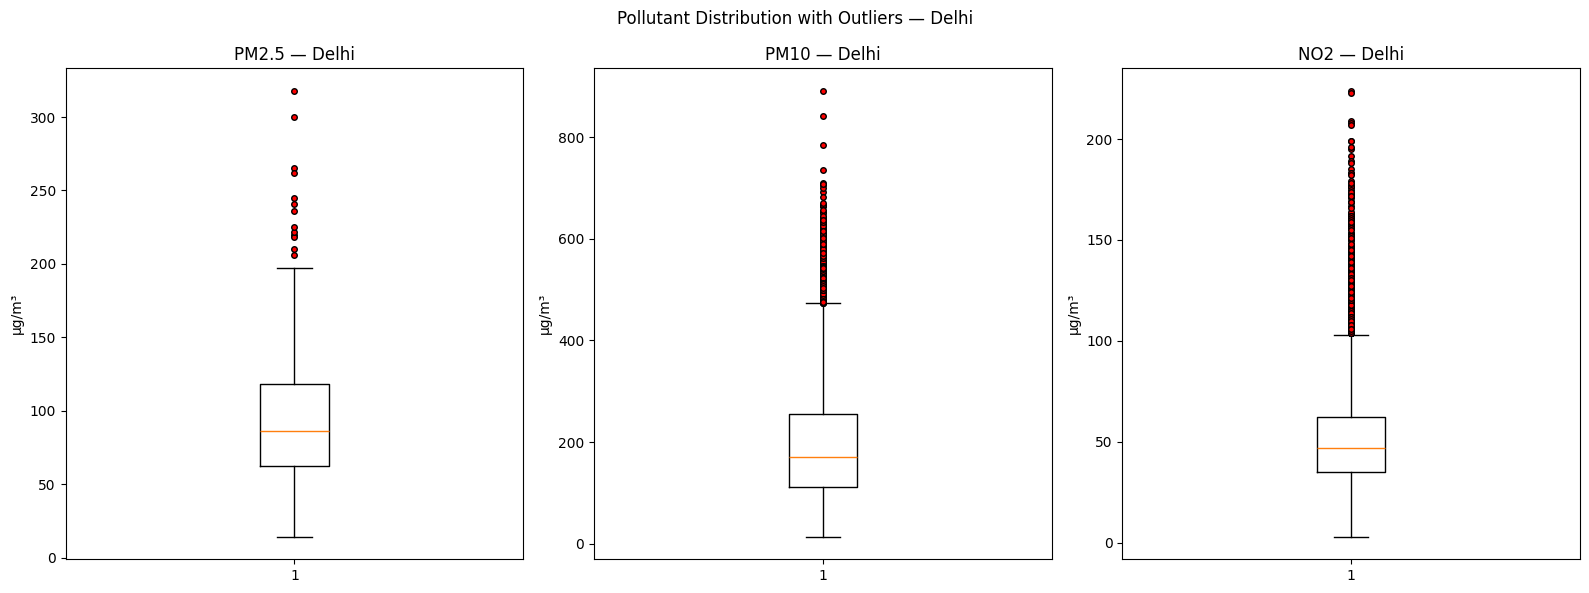

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

pollutants = [
    ("pm2_5", "PM2.5", axes[0]),
    ("rspm",  "PM10",  axes[1]),
    ("no2",   "NO2",   axes[2]),
]

for col, name, ax in pollutants:
    data = delhi[col].dropna()
    
    ax.boxplot(data,
               flierprops=dict(marker="o",
                               markerfacecolor="red",
                               markersize=4))
    ax.set_title(f"{name} — Delhi")
    ax.set_ylabel("µg/m³")

plt.suptitle("Pollutant Distribution with Outliers — Delhi")
plt.tight_layout()
plt.savefig("boxplot_pollutants.png", dpi=150)
plt.show()

### What I see per pollutant-
- PM2.5: 13 outliers, upper bound 204.5
- PM10:  186 outliers, upper bound 473.5
- NO2:   565 outliers, upper bound 103.5 (narrow IQR makes this count misleadingly high)

### Two outliers I investigated
- Reading 1: 16-10-15, PM2.5 = 318.0
→ Mid-October - early Diwali season pollution spike

- Reading 2: 10-11-15, PM2.5 = 300.0
→ November - Diwali + crop-burning season overlap, North India's worst air quality window